# 🎾 Tennis Analytics — Exploratory Data Analysis

**Project:** ATP Tennis Matchup Prediction  
**Data:** Jeff Sackmann ATP Dataset (1990–2024)  
**Matches:** 108,573 | **Players:** 3,000+

---

### Sections
1. Data Overview & Shape
2. Surface Distribution
3. Top Players by Win Rate
4. Serve Stats Distribution
5. Elo Rating Distribution
6. Year-by-Year Match Volume
7. Upset Analysis
8. Big 3 Comparison


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Dark theme for all plots
plt.rcParams.update({
    "figure.facecolor":  "#0f0f1a",
    "axes.facecolor":    "#0f0f1a",
    "axes.edgecolor":    "#333",
    "axes.labelcolor":   "#aaa",
    "xtick.color":       "white",
    "ytick.color":       "white",
    "text.color":        "white",
    "grid.color":        "#333",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "legend.facecolor":  "#1a1a2e",
    "legend.edgecolor":  "#444",
    "legend.labelcolor": "white",
})

DATA_DIR = Path("../data")
ACCENT   = "#00d4ff"
ACCENT2  = "#ff6b6b"
SURFACE_COLORS = {
    "Hard": "#4A90D9", "Clay": "#C0622D",
    "Grass": "#2E8B57", "Carpet": "#8B6914"
}

print("✅ Imports done")

✅ Imports done


## 1. Data Overview & Shape

In [2]:
df  = pd.read_parquet(DATA_DIR / "matches_clean.parquet")
elo = pd.read_parquet(DATA_DIR / "elo_ratings.parquet")

print(f"📊 Matches  : {len(df):,}")
print(f"👤 Players  : {elo['player_name'].nunique():,}")
print(f"📅 Date range: {df['tourney_date'].min().date()} → {df['tourney_date'].max().date()}")
print(f"📋 Columns  : {df.shape[1]}")
df.head()

📊 Matches  : 108,573
👤 Players  : 3,672
📅 Date range: 1990-01-01 → 2024-12-18
📋 Columns  : 59


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,best_of,round,winner_id,...,l_1stServe_pct,w_1stWon_pct,l_1stWon_pct,w_2ndWon_pct,l_2ndWon_pct,w_bpSave_pct,l_bpSave_pct,rank_diff,upset,tourney_level_name
0,1990-339,Adelaide,Hard,32,A,1990-01-01,1,3,R32,101843,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,257.0,0,ATP 500
1,1990-339,Adelaide,Hard,32,A,1990-01-01,2,3,R32,100714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-19.0,1,ATP 500
2,1990-339,Adelaide,Hard,32,A,1990-01-01,3,3,R32,101529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-42.0,1,ATP 500
3,1990-339,Adelaide,Hard,32,A,1990-01-01,4,3,R32,100628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0,ATP 500
4,1990-339,Adelaide,Hard,32,A,1990-01-01,5,3,R32,101404,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.0,0,ATP 500


In [3]:
# Missing value summary
missing = df.isnull().mean().sort_values(ascending=False)
print("Top 15 columns by missing rate:")
print((missing.head(15) * 100).round(1).to_string())

Top 15 columns by missing rate:
w_bpSave_pct      19.6
minutes           14.8
l_bpSave_pct      12.3
l_2ndWon_pct      12.1
l_1stServe_pct    12.1
l_1stWon_pct      12.1
w_2ndWon_pct      12.1
l_SvGms           12.1
w_SvGms           12.1
w_1stWon_pct      12.1
w_1stServe_pct    12.1
w_df              12.1
w_2ndWon          12.1
w_1stWon          12.1
w_1stIn           12.1


In [4]:
# Basic stats
print("\nNumerical summary (key columns):")
key_cols = ["winner_rank","loser_rank","winner_age","loser_age",
            "w_1stServe_pct","w_bpSave_pct","minutes"]
df[key_cols].describe().round(3)


Numerical summary (key columns):


,winner_rank,loser_rank,winner_age,loser_age,w_1stServe_pct,w_bpSave_pct,minutes
count,107327.000,105915.000,108564.000,108549.000,95417.000,87292.000,92466.000
mean,80.726,119.807,25.734,25.838,0.611,0.658,105.456
std,134.118,179.389,3.824,3.941,0.085,0.274,38.767
min,1.000,1.000,14.300,14.500,0.281,0.000,25.000
25%,18.000,37.000,22.900,23.000,0.554,0.500,76.000
50%,46.000,71.000,25.400,25.600,0.611,0.667,98.000
75%,89.000,120.000,28.200,28.400,0.667,0.857,127.000
max,2101.000,2159.000,44.600,44.000,1.000,1.000,396.000


## 2. Surface Distribution

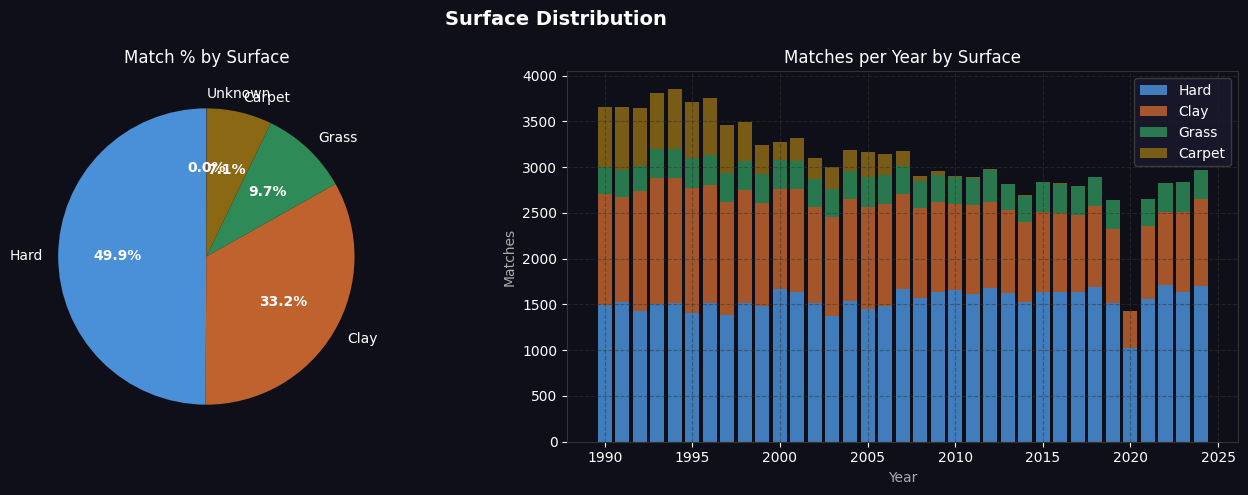

surface
Hard       54191
Clay       36088
Grass      10519
Carpet      7724
Unknown       51


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Surface Distribution", fontsize=14, fontweight="bold")

surf_counts = df["surface"].value_counts()
colors = [SURFACE_COLORS.get(s, "#555") for s in surf_counts.index]

# Pie
wedges, texts, autotexts = axes[0].pie(
    surf_counts.values, labels=surf_counts.index,
    colors=colors, autopct="%1.1f%%", startangle=90,
    textprops={"color": "white"}
)
for at in autotexts: at.set_fontweight("bold")
axes[0].set_title("Match % by Surface")

# Bar by year
df["year"] = df["tourney_date"].dt.year
surf_year = df.groupby(["year","surface"]).size().unstack(fill_value=0)
surf_year = surf_year[[s for s in ["Hard","Clay","Grass","Carpet"] if s in surf_year.columns]]
bottom = np.zeros(len(surf_year))
for surf in surf_year.columns:
    axes[1].bar(surf_year.index, surf_year[surf], bottom=bottom,
               label=surf, color=SURFACE_COLORS.get(surf,"#555"), alpha=0.85)
    bottom += surf_year[surf].values
axes[1].set_title("Matches per Year by Surface")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Matches")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(surf_counts.to_string())

## 3. Top Players by Win Rate

In [6]:
player_stats = []
for pid in elo[elo["matches_overall"] >= 100]["player_id"]:
    w = (df["winner_id"] == pid).sum()
    l = (df["loser_id"]  == pid).sum()
    name = elo[elo["player_id"]==pid]["player_name"].values[0]
    if w+l >= 100:
        player_stats.append({
            "name": name, "wins": w, "losses": l,
            "total": w+l, "win_rate": w/(w+l)
        })

ps_df = pd.DataFrame(player_stats).sort_values("win_rate", ascending=False)
print(f"Players with 100+ matches: {len(ps_df)}")
ps_df.head(10)

Players with 100+ matches: 526


,name,wins,losses,total,win_rate
0,Novak Djokovic,1095,208,1303,0.840368
3,Rafael Nadal,1057,219,1276,0.828370
1,Roger Federer,1230,275,1505,0.817276
11,Pete Sampras,729,186,915,0.796721
4,Carlos Alcaraz,203,53,256,0.792969
2,Jannik Sinner,259,75,334,0.775449
9,Andre Agassi,723,210,933,0.774920
14,Andy Roddick,599,200,799,0.749687
15,Boris Becker,399,134,533,0.748593
60,Andy Murray,721,259,980,0.735714


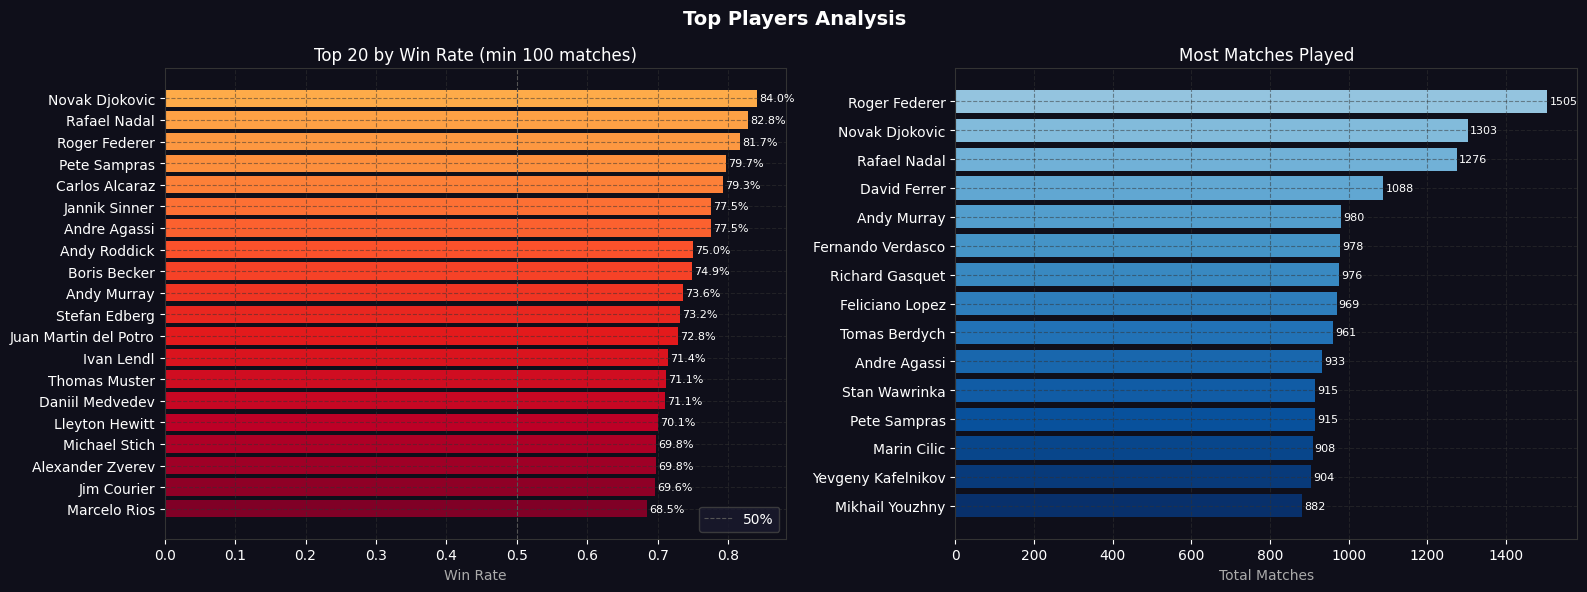

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top Players Analysis", fontsize=14, fontweight="bold")

top20 = ps_df.head(20)
colors_wr = plt.cm.YlOrRd(np.linspace(0.4, 1, len(top20)))[::-1]
axes[0].barh(top20["name"][::-1], top20["win_rate"][::-1], color=colors_wr)
axes[0].axvline(0.5, color="#555", ls="--", lw=0.8, label="50%")
for i, (_, row) in enumerate(top20[::-1].iterrows()):
    axes[0].text(row["win_rate"]+0.003, i, f"{row['win_rate']*100:.1f}%",
                va="center", fontsize=8)
axes[0].set_title("Top 20 by Win Rate (min 100 matches)")
axes[0].set_xlabel("Win Rate")
axes[0].legend()
axes[0].grid(True)

most = ps_df.sort_values("total", ascending=False).head(15)
colors_m = plt.cm.Blues(np.linspace(0.4,1,len(most)))[::-1]
axes[1].barh(most["name"][::-1], most["total"][::-1], color=colors_m)
for i, (_, row) in enumerate(most[::-1].iterrows()):
    axes[1].text(row["total"]+5, i, str(row["total"]), va="center", fontsize=8)
axes[1].set_title("Most Matches Played")
axes[1].set_xlabel("Total Matches")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Serve Stats Distribution

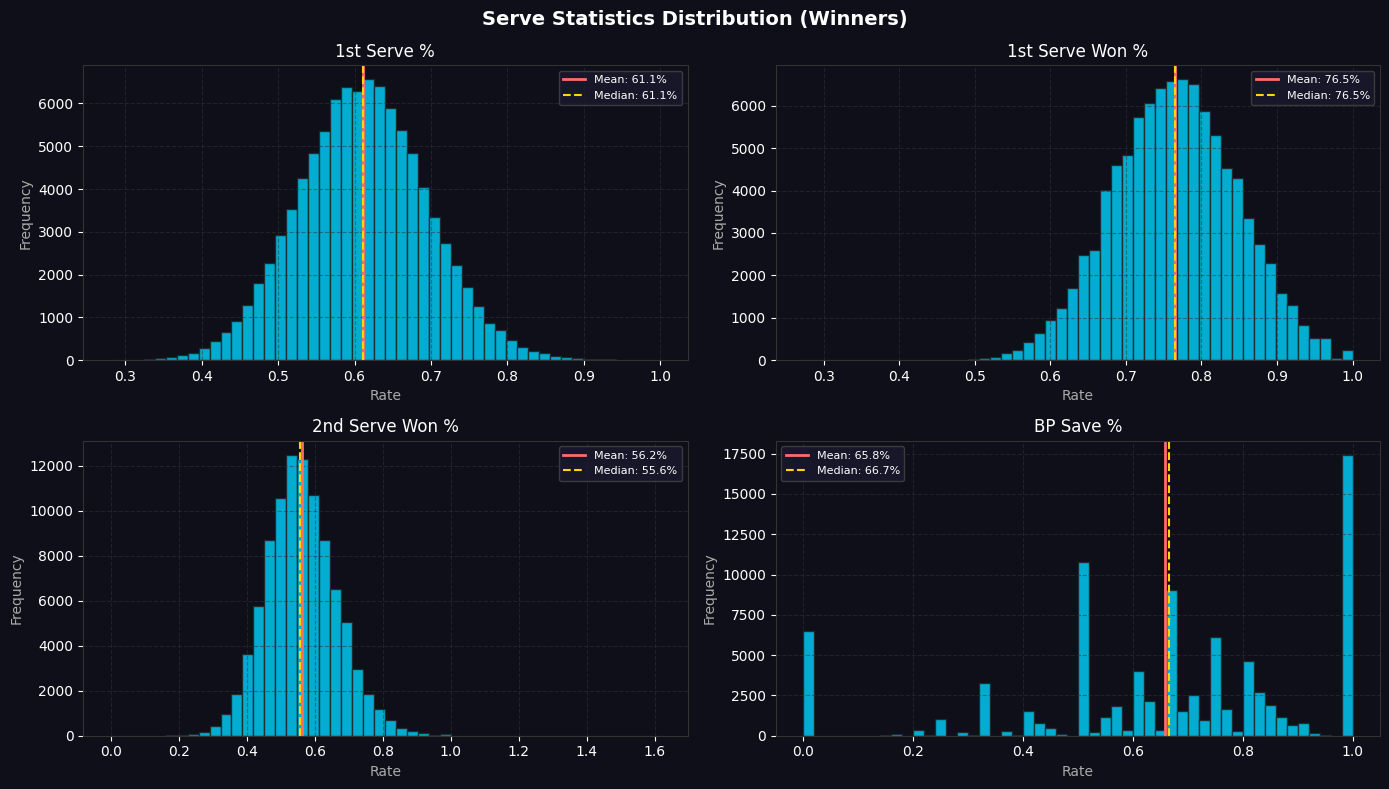

In [8]:
serve_cols = {
    "w_1stServe_pct": "1st Serve %",
    "w_1stWon_pct":   "1st Serve Won %",
    "w_2ndWon_pct":   "2nd Serve Won %",
    "w_bpSave_pct":   "BP Save %",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Serve Statistics Distribution (Winners)", fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes.flatten(), serve_cols.items()):
    if col in df.columns:
        data = df[col].dropna()
        ax.hist(data, bins=50, color=ACCENT, alpha=0.8, edgecolor="#222")
        ax.axvline(data.mean(),   color=ACCENT2,    lw=2, label=f"Mean: {data.mean()*100:.1f}%")
        ax.axvline(data.median(), color="#FFD700", lw=1.5, ls="--", label=f"Median: {data.median()*100:.1f}%")
        ax.legend(fontsize=8)
        ax.set_title(label)
        ax.set_xlabel("Rate"); ax.set_ylabel("Frequency")
        ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Elo Rating Distribution

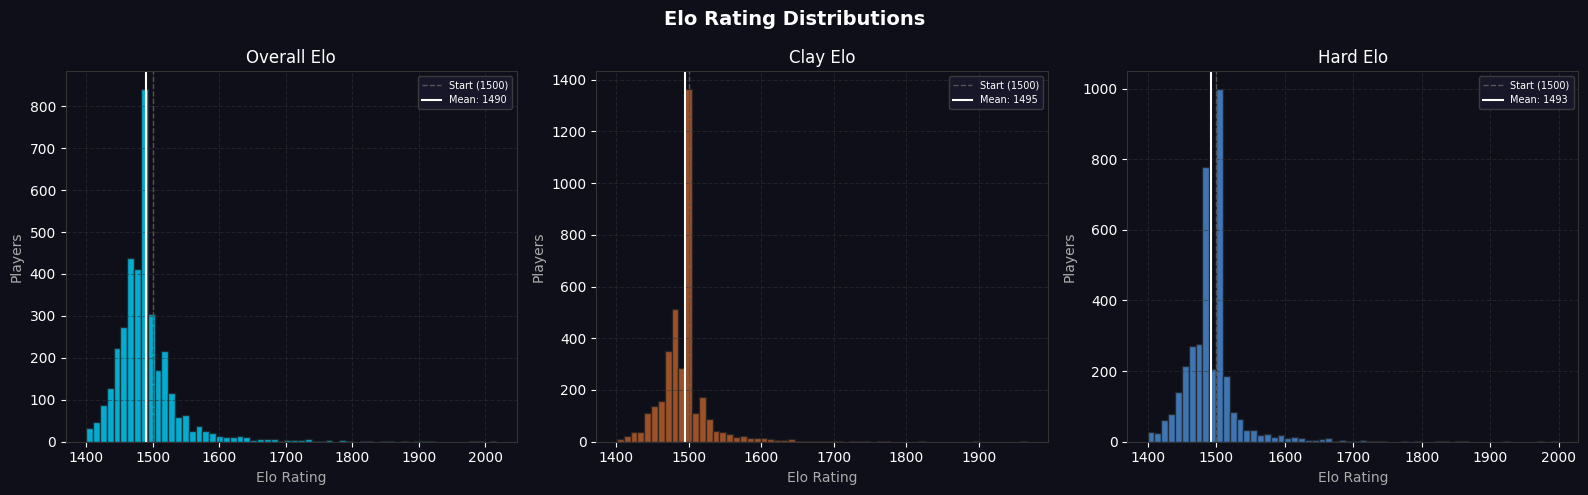


Top 10 by Overall Elo:
          player_name  elo_overall  elo_hard  elo_clay  elo_grass
       Novak Djokovic      2016.85   1998.92   1895.66    1811.38
        Roger Federer      1994.15   1970.42   1822.19    1828.61
        Jannik Sinner      1981.88   1925.62   1668.05    1584.63
         Rafael Nadal      1922.36   1853.55   1966.97    1700.20
       Carlos Alcaraz      1906.26   1775.09   1761.78    1655.79
Juan Martin del Potro      1896.41   1867.19   1703.63    1621.89
      Robin Soderling      1878.73   1774.45   1708.31    1566.41
     Alexander Zverev      1852.68   1797.84   1771.16    1592.06
      Daniil Medvedev      1842.45   1827.80   1582.24    1605.67
         Andre Agassi      1827.80   1820.80   1683.53    1652.56


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Elo Rating Distributions", fontsize=14, fontweight="bold")

surfaces_elo = [("elo_overall","Overall",ACCENT),
                ("elo_clay","Clay","#C0622D"),
                ("elo_hard","Hard","#4A90D9")]

for ax, (col, label, color) in zip(axes, surfaces_elo):
    data = elo[elo[col] > 1400][col]
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor="#222")
    ax.axvline(1500,        color="#555",     ls="--", lw=1,   label="Start (1500)")
    ax.axvline(data.mean(), color="white",    lw=1.5,          label=f"Mean: {data.mean():.0f}")
    ax.legend(fontsize=7)
    ax.set_title(f"{label} Elo")
    ax.set_xlabel("Elo Rating"); ax.set_ylabel("Players")
    ax.grid(True)

plt.tight_layout()
plt.show()

print("\nTop 10 by Overall Elo:")
print(elo.nlargest(10,"elo_overall")[["player_name","elo_overall","elo_hard","elo_clay","elo_grass"]].to_string(index=False))

## 6. Year-by-Year Match Volume

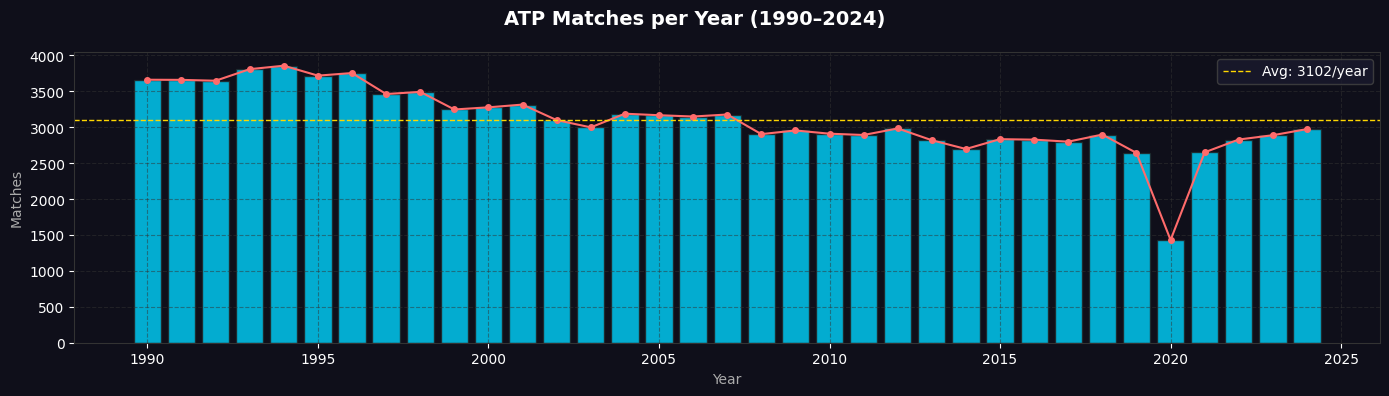

Peak year : 1994 (3855 matches)
Avg/year  : 3102


In [10]:
yearly = df.groupby("year").size().reset_index(name="matches")

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("ATP Matches per Year (1990–2024)", fontsize=14, fontweight="bold")

ax.bar(yearly["year"], yearly["matches"], color=ACCENT, alpha=0.8, edgecolor="#222")
ax.plot(yearly["year"], yearly["matches"], "o-", color=ACCENT2, lw=1.5, ms=4)
ax.axhline(yearly["matches"].mean(), color="#FFD700", ls="--", lw=1,
           label=f"Avg: {yearly['matches'].mean():.0f}/year")
ax.set_xlabel("Year"); ax.set_ylabel("Matches")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Peak year : {yearly.loc[yearly['matches'].idxmax(), 'year']} ({yearly['matches'].max()} matches)")
print(f"Avg/year  : {yearly['matches'].mean():.0f}")

## 7. Upset Analysis

In [11]:
df_u = df.dropna(subset=["rank_diff","upset"])
upset_rate = df_u["upset"].mean()
upset_by_surface = df_u.groupby("surface")["upset"].mean()

print(f"Overall upset rate: {upset_rate*100:.1f}%")
print("\nUpset rate by surface:")
print((upset_by_surface*100).round(1).to_string())

Overall upset rate: 34.4%

Upset rate by surface:
surface
Carpet     35.4
Clay       35.2
Grass      34.7
Hard       33.8
Unknown    26.5


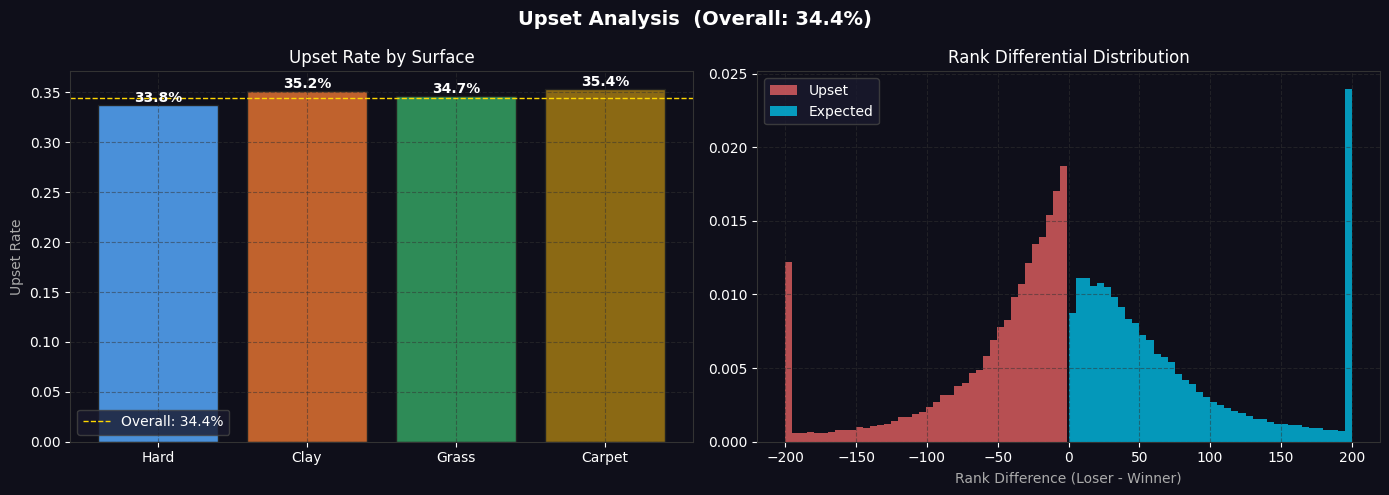

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Upset Analysis  (Overall: {upset_rate*100:.1f}%)", fontsize=14, fontweight="bold")

# By surface
surf_upsets = upset_by_surface.reindex(["Hard","Clay","Grass","Carpet"]).dropna()
colors_u = [SURFACE_COLORS.get(s,"#555") for s in surf_upsets.index]
axes[0].bar(surf_upsets.index, surf_upsets.values, color=colors_u, edgecolor="#222")
axes[0].axhline(upset_rate, color="#FFD700", ls="--", lw=1, label=f"Overall: {upset_rate*100:.1f}%")
for i, (s, v) in enumerate(surf_upsets.items()):
    axes[0].text(i, v+0.003, f"{v*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Upset Rate by Surface")
axes[0].set_ylabel("Upset Rate")
axes[0].legend()
axes[0].grid(True)

# Rank diff distribution
axes[1].hist(df_u[df_u["upset"]==1]["rank_diff"].clip(-200,0),   bins=40, color=ACCENT2, alpha=0.7, label="Upset",    density=True)
axes[1].hist(df_u[df_u["upset"]==0]["rank_diff"].clip(0,200),    bins=40, color=ACCENT,  alpha=0.7, label="Expected", density=True)
axes[1].set_title("Rank Differential Distribution")
axes[1].set_xlabel("Rank Difference (Loser - Winner)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Big 3 Comparison — Djokovic vs Nadal vs Federer

KeyError: "['w_elo_overall'] not in index"

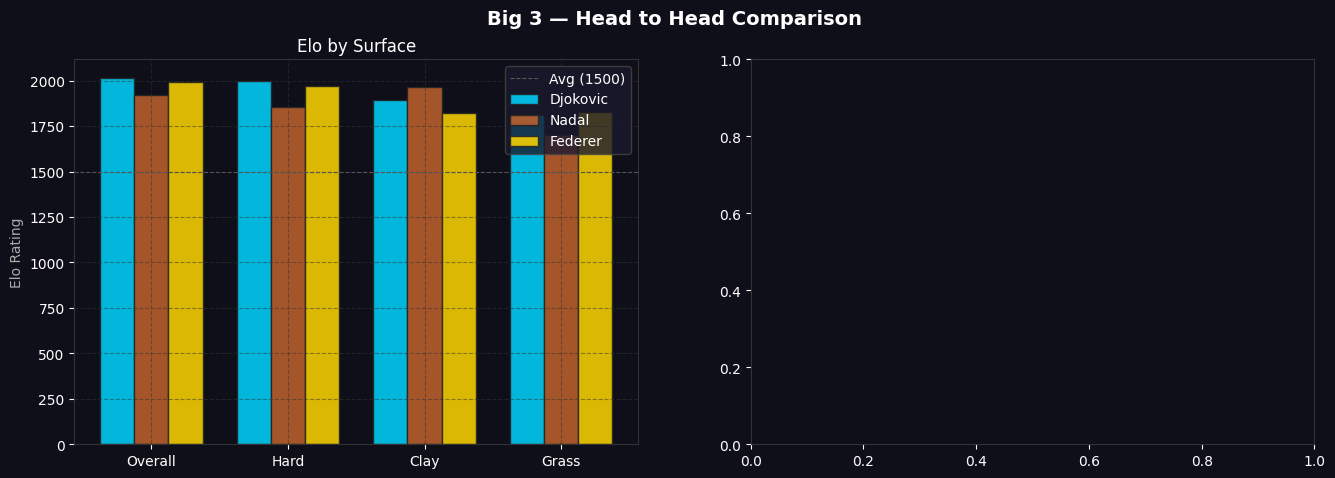

In [13]:
big3 = ["Novak Djokovic", "Rafael Nadal", "Roger Federer"]
big3_colors = ["#00d4ff", "#C0622D", "#FFD700"]
surfs = ["overall","hard","clay","grass"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Big 3 — Head to Head Comparison", fontsize=14, fontweight="bold")

# Elo comparison
x = np.arange(len(surfs)); width = 0.25
for i, (name, color) in enumerate(zip(big3, big3_colors)):
    row = elo[elo["player_name"]==name]
    if not row.empty:
        vals = [row.iloc[0].get(f"elo_{s}", 1500) for s in surfs]
        axes[0].bar(x + i*width, vals, width, label=name.split()[-1],
                   color=color, alpha=0.85, edgecolor="#222")
axes[0].set_xticks(x+width)
axes[0].set_xticklabels([s.capitalize() for s in surfs])
axes[0].axhline(1500, color="#555", ls="--", lw=0.8, label="Avg (1500)")
axes[0].legend()
axes[0].set_title("Elo by Surface")
axes[0].set_ylabel("Elo Rating")
axes[0].grid(True)

# Career timeline
for name, color in zip(big3, big3_colors):
    row = elo[elo["player_name"]==name]
    if row.empty: continue
    pid = row.iloc[0]["player_id"]
    w_ = df[df["winner_id"]==pid][["tourney_date","w_elo_overall"]].rename(columns={"w_elo_overall":"elo"})
    l_ = df[df["loser_id"]==pid][["tourney_date","l_elo_overall"]].rename(columns={"l_elo_overall":"elo"})
    tl = pd.concat([w_,l_]).sort_values("tourney_date").dropna()
    if len(tl) > 10:
        tl = tl.set_index("tourney_date").resample("ME").mean().dropna().reset_index()
        axes[1].plot(tl["tourney_date"], tl["elo"], color=color,
                    lw=2.5, label=name.split()[-1], alpha=0.9)

axes[1].axhline(1500, color="#555", ls="--", lw=0.8, label="Avg (1500)")
axes[1].legend()
axes[1].set_title("Career Elo Timeline")
axes[1].set_ylabel("Elo Rating")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 📋 Key Findings Summary

In [ ]:
print("="*55)
print("  KEY FINDINGS — Tennis Analytics EDA")
print("="*55)
print(f"  Total matches    : {len(df):,}")
print(f"  Unique players   : {elo['player_name'].nunique():,}")
print(f"  Date range       : {df['tourney_date'].min().date()} → {df['tourney_date'].max().date()}")
print(f"  Upset rate       : {df_u['upset'].mean()*100:.1f}%")
print(f"  Most matches/yr  : {yearly.loc[yearly['matches'].idxmax(),'year']}")
print()
print("  Top Elo Rankings:")
for surf in ["overall","hard","clay","grass"]:
    top = elo.nlargest(1, f"elo_{surf}").iloc[0]
    print(f"    {surf.capitalize():<10}: {top['player_name']} ({top[f'elo_{surf}']:.0f})")
print()
print("  Most dominant surfaces:")
for surf in ["Hard","Clay","Grass"]:
    wr = df_u.groupby("surface")["upset"].mean().get(surf, 0)
    print(f"    {surf:<8}: {(1-wr)*100:.1f}% predictable (favourite wins)")
print("="*55)